In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

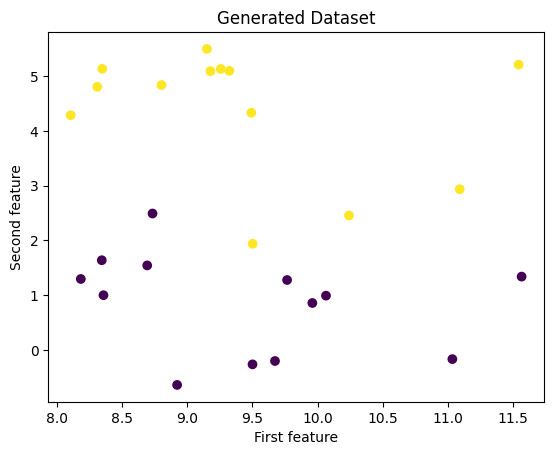

X.shape: (26, 2)


In [3]:
from sklearn.datasets import make_blobs

# generate dataset
X, y = make_blobs(n_samples=26, centers=2, random_state=4, n_features=2)
# plot dataset
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis')
plt.xlabel("First feature")
plt.ylabel("Second feature")
plt.title("Generated Dataset")
plt.show()
print("X.shape: {}".format(X.shape))

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

In [5]:
from sklearn.neighbors import KNeighborsClassifier

clf = KNeighborsClassifier(n_neighbors=3)

In [6]:
clf.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

In [7]:
print("Test set predictions: ", clf.predict(X_test))

Test set predictions:  [0 0 1 1 0 1 0]


In [8]:
print(f"Test set accuracy: {clf.score(X_test, y_test):.2f}")

Test set accuracy: 0.86


In [9]:
# Plotting grid parameters (constant for all plots)
h = 0.02
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

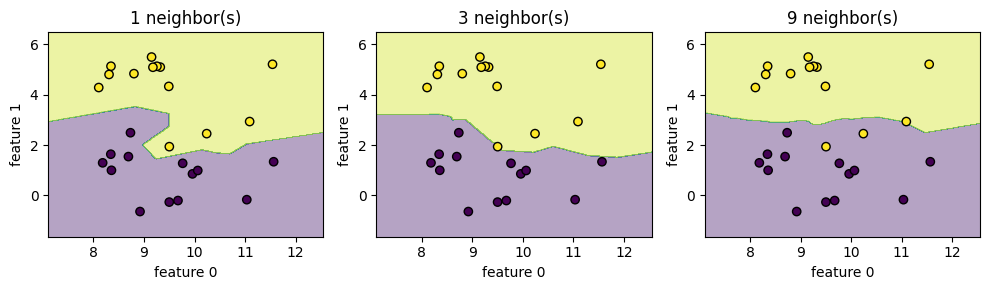

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(10, 3))

for n_neighbors, ax in zip([1, 3, 9], axes):
    
    clf = KNeighborsClassifier(n_neighbors=n_neighbors).fit(X, y)
    
    # Predict on the grid (Creating the decision boundary)
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])  
    Z = Z.reshape(xx.shape)
    
    # Plot decision boundary (fitted area)
    ax.contourf(xx, yy, Z, alpha=.4, cmap='viridis')
    
    # Plot the training points
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', edgecolor='k')
    
    # Set labels and title
    ax.set_title("{} neighbor(s)".format(n_neighbors))
    ax.set_xlabel("feature 0")
    ax.set_ylabel("feature 1")

# axes[0].legend(loc=3)
plt.tight_layout()
plt.show()

# real-world Breast Cancer dataset

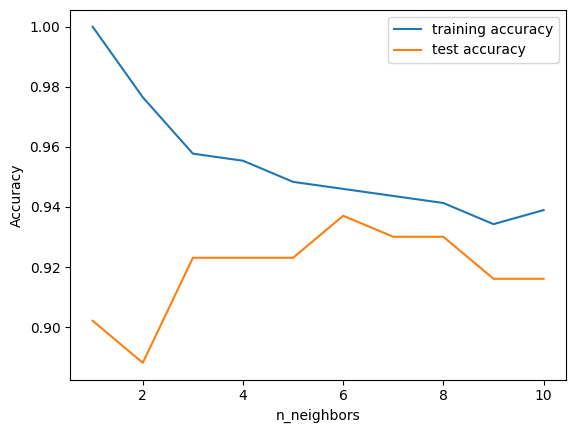

In [11]:
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(
    cancer.data, cancer.target, stratify=cancer.target, random_state=66)

training_accuracy = []
test_accuracy = []
# try n_neighbors from 1 to 10
neighbors_settings = range(1, 11)

for n_neighbors in neighbors_settings:
    
    clf = KNeighborsClassifier(n_neighbors=n_neighbors)
    clf.fit(X_train, y_train)
    
    training_accuracy.append(clf.score(X_train, y_train))
    test_accuracy.append(clf.score(X_test, y_test))
    

plt.plot(neighbors_settings, training_accuracy, label="training accuracy")
plt.plot(neighbors_settings, test_accuracy, label="test accuracy")
plt.ylabel("Accuracy")
plt.xlabel("n_neighbors")
plt.legend()

# K-Neighbors-Regression

In [12]:
from sklearn.datasets import make_regression
from sklearn.neighbors import KNeighborsRegressor

X, y = make_regression(n_samples=40, n_features=1, n_informative=1, noise=10, random_state=0)

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

reg = KNeighborsRegressor(n_neighbors=3)
reg.fit(X_train, y_train)

print("Test set prediction:\n{}".format(reg.predict(X_test)))

Test set prediction:
[-15.95848314  -5.21087244   0.27385734 -28.78322724 -10.42141415
  59.04341602 -15.95848314   0.69687546  63.50606988 -50.59453486]


In [13]:
print("Test set R^2: {:.2f}".format(reg.score(X_test, y_test)))

Test set R^2: 0.87


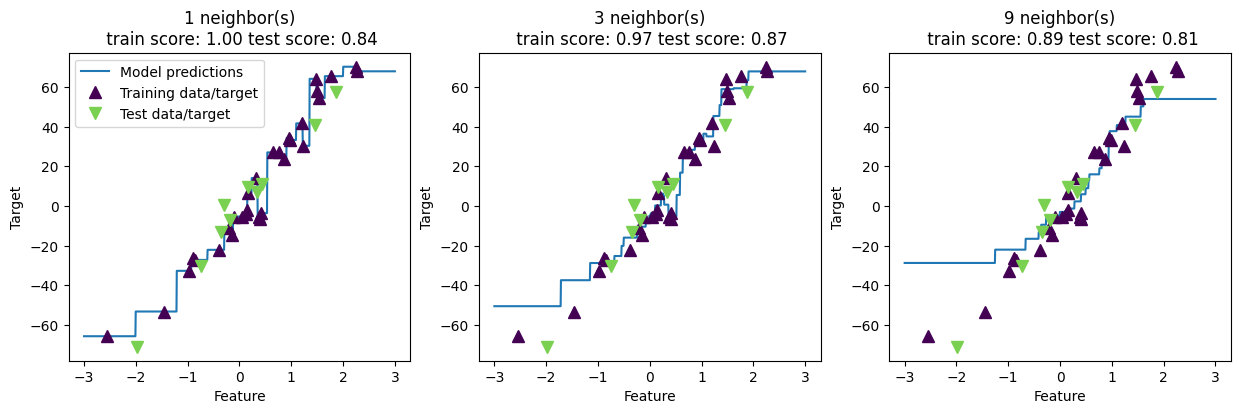

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# create 1,000 data points, evenly spaced between -3 and 3
line = np.linspace(-3, 3, 1000).reshape(-1, 1)

for n_neighbors, ax in zip([1, 3, 9], axes): 
    
    # make predictions using 1, 3, or 9 neighbors
    reg = KNeighborsRegressor(n_neighbors=n_neighbors)
    reg.fit(X_train, y_train)
    
    cmap = plt.get_cmap('viridis') 
    ax.plot(line, reg.predict(line))
    ax.plot(X_train, y_train, '^', c=cmap(0.0), markersize=8)
    ax.plot(X_test, y_test, 'v', c=cmap(0.8), markersize=8)
    
    ax.set_title(
        "{} neighbor(s)\n train score: {:.2f} test score: {:.2f}".format(
            n_neighbors, reg.score(X_train, y_train),
            reg.score(X_test, y_test)))
    ax.set_xlabel("Feature")
    ax.set_ylabel("Target")
axes[0].legend(["Model predictions", "Training data/target",
"Test data/target"], loc="best")